<a href="https://colab.research.google.com/github/DhanushV2006/AIML/blob/main/5_SYM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
iris = datasets.load_iris()

X = iris.data[:, :2]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:
kernels = {
    "Linear" : SVC(kernel="linear", C=1.0),
    "Polynomial" : SVC(kernel="poly", degree=3, C=1.0),
    "RBF" : SVC(kernel="rbf", gamma=0.1, C=1.0),
    "Sigmoid": SVC(kernel="sigmoid", C=1.0)
}

def plot_svm(X, y, model, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


Linear Kernel Accuracy: 0.73
Confusion Matrix:
 [[19  0  0]
 [ 0  7  6]
 [ 0  6  7]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



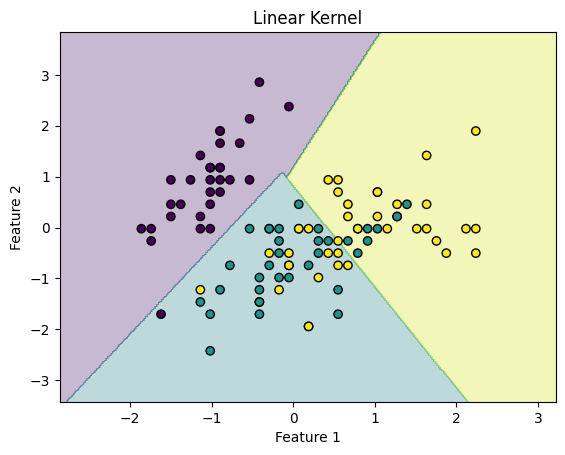


Polynomial Kernel Accuracy: 0.76
Confusion Matrix:
 [[19  0  0]
 [ 0 11  2]
 [ 0  9  4]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.55      0.85      0.67        13
           2       0.67      0.31      0.42        13

    accuracy                           0.76        45
   macro avg       0.74      0.72      0.70        45
weighted avg       0.77      0.76      0.74        45



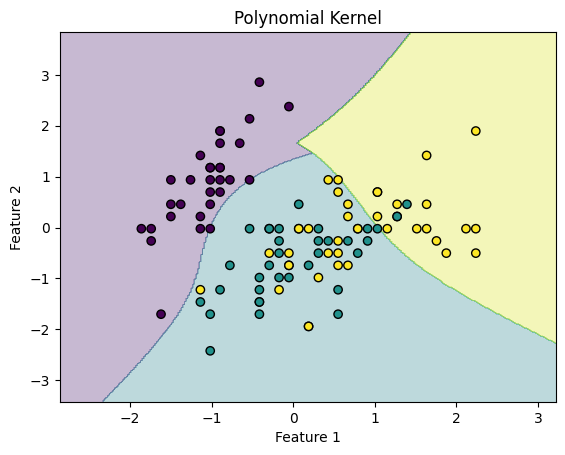


RBF Kernel Accuracy: 0.73
Confusion Matrix:
 [[19  0  0]
 [ 0  7  6]
 [ 0  6  7]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



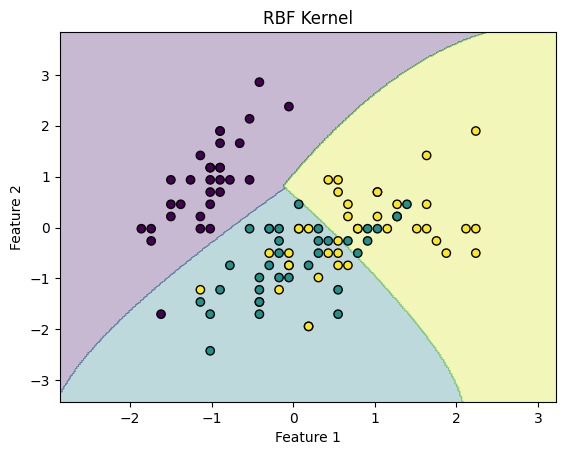


Sigmoid Kernel Accuracy: 0.78
Confusion Matrix:
 [[19  0  0]
 [ 1  5  7]
 [ 0  2 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.71      0.38      0.50        13
           2       0.61      0.85      0.71        13

    accuracy                           0.78        45
   macro avg       0.76      0.74      0.73        45
weighted avg       0.78      0.78      0.76        45



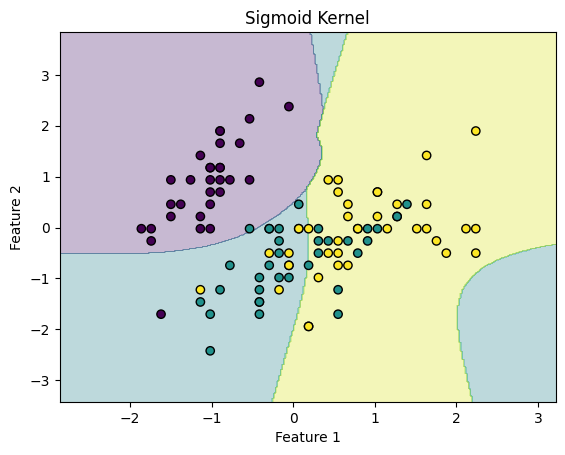

In [5]:
# Train and compare
accuracy_results = {}

for name, model in kernels.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc

    print(f"\n{name} Kernel Accuracy: {acc:.2f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    plot_svm(X_train, y_train, model, f"{name} Kernel")